In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd

In [ ]:

BASE_PATH = "/content/drive/MyDrive/Stock_Project/"

cib = pd.read_csv(BASE_PATH + "features_cib.csv")

cae = pd.read_csv(BASE_PATH + "features_cae.csv")

hdb = pd.read_csv(BASE_PATH + "features_hdb.csv")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
def create_features(df):

    df = df.copy()

    # ---------------------------------------------------
    # PREVIOUS DAY FEATURES
    # ---------------------------------------------------

    df['Previous_Close'] = df['Close'].shift(1)

    df['Previous_Open'] = df['Open'].shift(1)

    df['Previous_High'] = df['High'].shift(1)

    df['Previous_Low'] = df['Low'].shift(1)

    df['Previous_Volume'] = df['Volume'].shift(1)

    # ---------------------------------------------------
    # MOVING AVERAGES
    # ---------------------------------------------------

    df['MA_5'] = df['Close'].rolling(window=5).mean()

    df['MA_10'] = df['Close'].rolling(window=10).mean()

    # ---------------------------------------------------
    # DAILY RETURN
    # ---------------------------------------------------

    df['Daily_Return'] = df['Close'].pct_change()

    # ---------------------------------------------------
    # REMOVE INF VALUES
    # ---------------------------------------------------

    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # ---------------------------------------------------
    # REMOVE NaN VALUES
    # ---------------------------------------------------

    df.dropna(inplace=True)

    return df

In [ ]:
cib = create_features(cib)

cae = create_features(cae)

hdb = create_features(hdb)

In [ ]:
def run_real_linear_regression(df, dataset_name):

    print("\n" + "=" * 60)
    print(f"REAL LINEAR REGRESSION FOR: {dataset_name}")
    print("=" * 60)

    # ---------------------------------------------------
    # FEATURES & TARGET
    # ---------------------------------------------------

    features = [
        'Previous_Close',
        'Previous_Open',
        'Previous_High',
        'Previous_Low',
        'Previous_Volume',
        'MA_5',
        'MA_10',
        'Daily_Return'
    ]

    X = df[features]

    y = df['Close']

    # ---------------------------------------------------
    # TRAIN TEST SPLIT
    # ---------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # ---------------------------------------------------
    # FEATURE SCALING
    # ---------------------------------------------------

    scaler = MinMaxScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    # ---------------------------------------------------
    # BUILD MODEL
    # ---------------------------------------------------

    model = LinearRegression()

    # ---------------------------------------------------
    # TRAIN MODEL
    # ---------------------------------------------------

    model.fit(X_train_scaled, y_train)

    # ---------------------------------------------------
    # PREDICTIONS
    # ---------------------------------------------------

    predictions = model.predict(X_test_scaled)

    # ---------------------------------------------------
    # EVALUATION
    # ---------------------------------------------------

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    # ---------------------------------------------------
    # MAPE (REAL FORECAST ACCURACY)
    # ---------------------------------------------------

    mape = np.mean(
        np.abs((y_test - predictions) / y_test)
    ) * 100

    forecast_accuracy = 100 - mape

    # ---------------------------------------------------
    # PRINT RESULTS
    # ---------------------------------------------------

    print("\nMODEL RESULTS")

    print(f"MAE: {mae:.4f}")

    print(f"RMSE: {rmse:.4f}")

    print(f"R2 Score: {r2:.4f}")

    print(f"MAPE: {mape:.2f}%")

    print(f"Forecast Accuracy: {forecast_accuracy:.2f}%")

    # ---------------------------------------------------
    # ACTUAL VS PREDICTED
    # ---------------------------------------------------

    plt.figure(figsize=(14,6))

    plt.plot(y_test.values, label='Actual Prices')

    plt.plot(predictions, label='Predicted Prices')

    plt.title(f'{dataset_name} - Real Linear Regression')

    plt.xlabel('Days')

    plt.ylabel('Stock Price')

    plt.legend()

    plt.show()

    # ---------------------------------------------------
    # RETURN RESULTS
    # ---------------------------------------------------

    return {
        'Dataset': dataset_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE (%)': mape,
        'Forecast Accuracy (%)': forecast_accuracy
    }


REAL LINEAR REGRESSION FOR: CIB

MODEL RESULTS
MAE: 0.2394
RMSE: 0.3844
R2 Score: 0.9907
MAPE: 1.21%
Forecast Accuracy: 98.79%


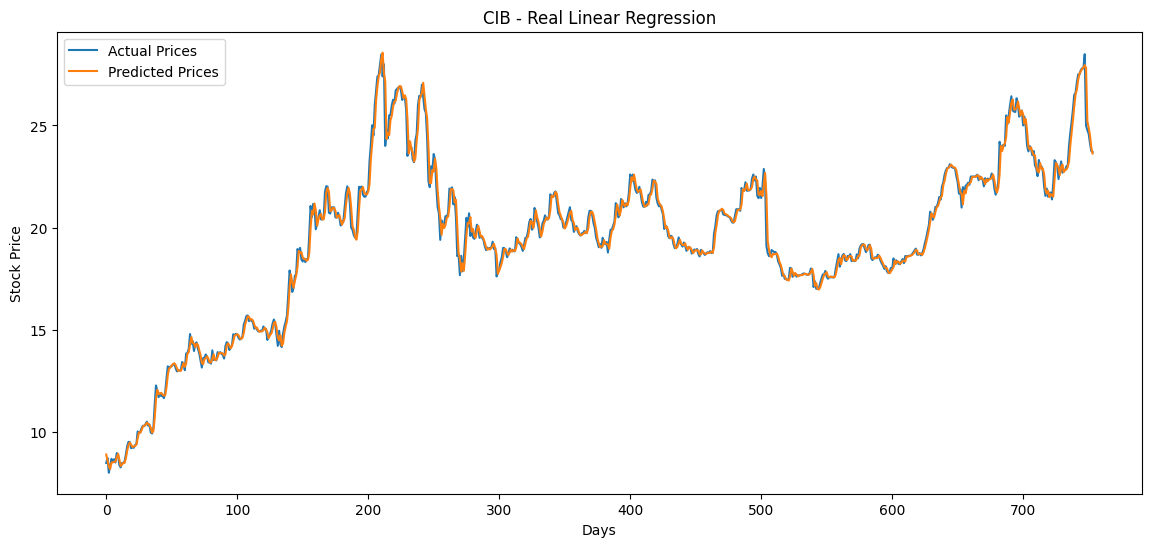


REAL LINEAR REGRESSION FOR: CAE

MODEL RESULTS
MAE: 0.8556
RMSE: 1.3143
R2 Score: 0.9965
MAPE: 1.02%
Forecast Accuracy: 98.98%


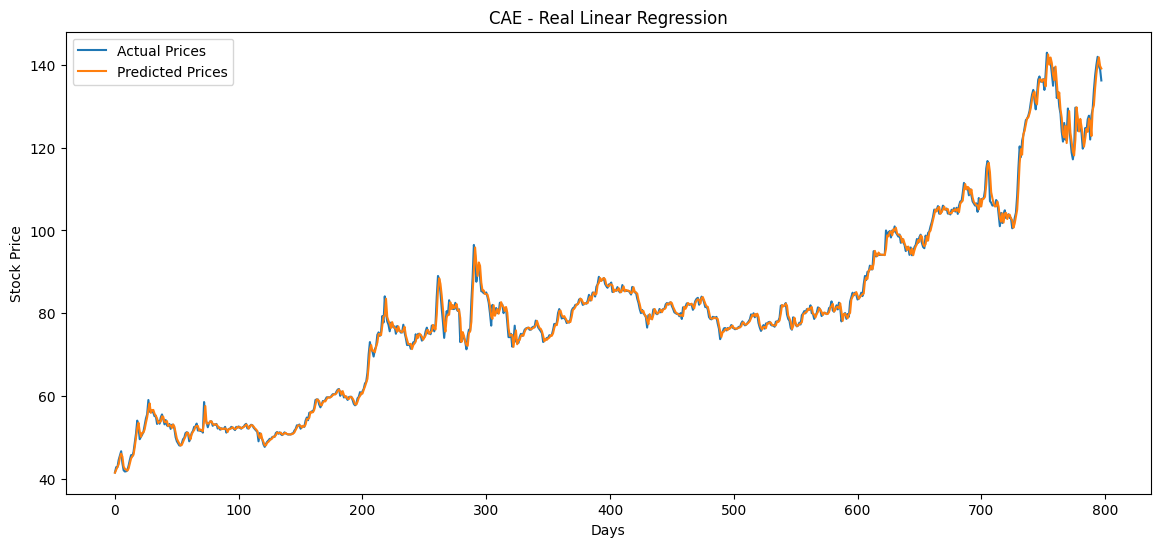


REAL LINEAR REGRESSION FOR: HDB

MODEL RESULTS
MAE: 0.6604
RMSE: 1.4522
R2 Score: 0.9973
MAPE: 1.12%
Forecast Accuracy: 98.88%


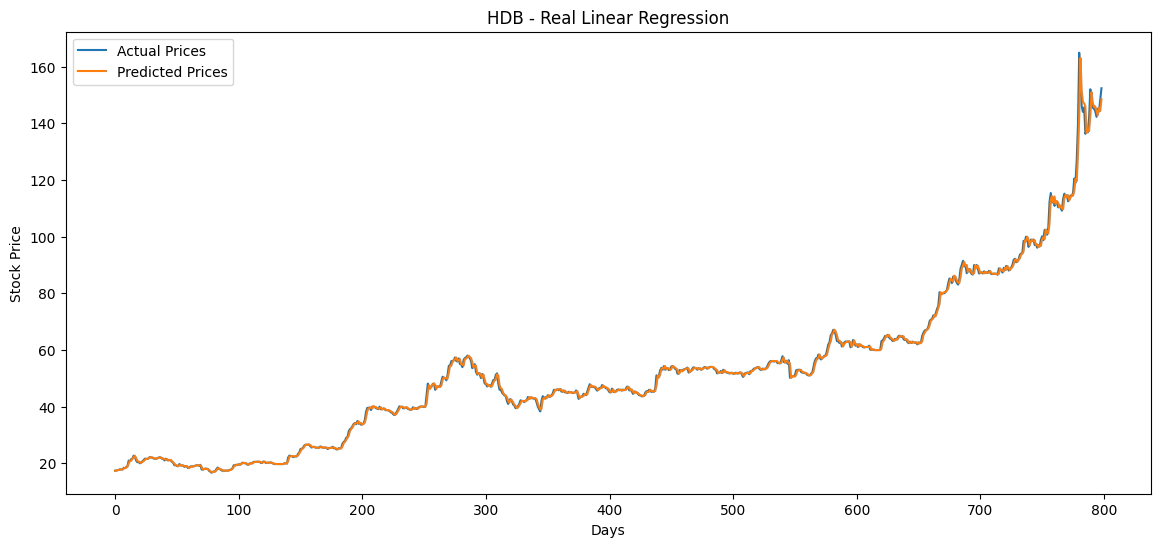

In [ ]:
cib_results = run_real_linear_regression(cib, "CIB")

cae_results = run_real_linear_regression(cae, "CAE")

hdb_results = run_real_linear_regression(hdb, "HDB")

In [ ]:
results = [
    cib_results,
    cae_results,
    hdb_results
]

results_df = pd.DataFrame(results)

print(results_df)

  Dataset       MAE      RMSE        R2  MAPE (%)  Forecast Accuracy (%)
0     CIB  0.239407  0.384436  0.990719  1.213504              98.786496
1     CAE  0.855646  1.314332  0.996494  1.017354              98.982646
2     HDB  0.660393  1.452202  0.997261  1.117389              98.882611


In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Dropout
)

from sklearn.preprocessing import MinMaxScaler

In [ ]:
def run_real_lstm(df, dataset_name):

    print("\n" + "=" * 60)
    print(f"REAL LSTM MODEL FOR: {dataset_name}")
    print("=" * 60)

    # ---------------------------------------------------
    # SELECT TARGET
    # ---------------------------------------------------

    data = df[['Close']]

    # ---------------------------------------------------
    # SCALE DATA
    # ---------------------------------------------------

    scaler = MinMaxScaler(feature_range=(0,1))

    scaled_data = scaler.fit_transform(data)

    # ---------------------------------------------------
    # CREATE SEQUENCES
    # ---------------------------------------------------

    sequence_length = 60

    X = []
    y = []

    for i in range(sequence_length, len(scaled_data)):

        X.append(
            scaled_data[i-sequence_length:i, 0]
        )

        y.append(
            scaled_data[i, 0]
        )

    X = np.array(X)

    y = np.array(y)

    # ---------------------------------------------------
    # RESHAPE FOR LSTM
    # ---------------------------------------------------

    X = np.reshape(
        X,
        (X.shape[0], X.shape[1], 1)
    )

    # ---------------------------------------------------
    # TRAIN TEST SPLIT
    # ---------------------------------------------------

    train_size = int(len(X) * 0.8)

    X_train = X[:train_size]

    X_test = X[train_size:]

    y_train = y[:train_size]

    y_test = y[train_size:]

    # ---------------------------------------------------
    # BUILD MODEL
    # ---------------------------------------------------

    model = Sequential()

    model.add(
        LSTM(
            units=64,
            return_sequences=True,
            input_shape=(X_train.shape[1], 1)
        )
    )

    model.add(Dropout(0.2))

    model.add(
        LSTM(
            units=64,
            return_sequences=False
        )
    )

    model.add(Dropout(0.2))

    model.add(Dense(25))

    model.add(Dense(1))

    # ---------------------------------------------------
    # COMPILE MODEL
    # ---------------------------------------------------

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    # ---------------------------------------------------
    # TRAIN MODEL
    # ---------------------------------------------------

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

    # ---------------------------------------------------
    # PREDICTIONS
    # ---------------------------------------------------

    predictions = model.predict(X_test)

    predictions = scaler.inverse_transform(
        predictions
    )

    y_test_actual = scaler.inverse_transform(
        y_test.reshape(-1,1)
    )

    # ---------------------------------------------------
    # EVALUATION
    # ---------------------------------------------------

    mae = mean_absolute_error(
        y_test_actual,
        predictions
    )

    mse = mean_squared_error(
        y_test_actual,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test_actual,
        predictions
    )

    # ---------------------------------------------------
    # REAL FORECAST ACCURACY
    # ---------------------------------------------------

    mape = np.mean(
        np.abs(
            (y_test_actual - predictions)
            / y_test_actual
        )
    ) * 100

    forecast_accuracy = 100 - mape

    # ---------------------------------------------------
    # PRINT RESULTS
    # ---------------------------------------------------

    print("\nLSTM RESULTS")

    print(f"MAE: {mae:.4f}")

    print(f"RMSE: {rmse:.4f}")

    print(f"R2 Score: {r2:.4f}")

    print(f"MAPE: {mape:.2f}%")

    print(f"Forecast Accuracy: {forecast_accuracy:.2f}%")

    # ---------------------------------------------------
    # ACTUAL VS PREDICTED GRAPH
    # ---------------------------------------------------

    plt.figure(figsize=(14,6))

    plt.plot(
        y_test_actual,
        label='Actual Prices'
    )

    plt.plot(
        predictions,
        label='Predicted Prices'
    )

    plt.title(f'{dataset_name} - LSTM')

    plt.xlabel('Days')

    plt.ylabel('Stock Price')

    plt.legend()

    plt.show()

    # ---------------------------------------------------
    # RETURN RESULTS
    # ---------------------------------------------------

    return {
        'Dataset': dataset_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE (%)': mape,
        'Forecast Accuracy (%)': forecast_accuracy
    }


REAL LSTM MODEL FOR: CIB
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 4.2029e-04 - val_loss: 0.0014
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - loss: 3.3398e-04 - val_loss: 0.0017
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 2.7368e-04 - val_loss: 0.0014
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 2.4777e-04 - val_loss: 0.0015
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 2.0401e-04 - val_loss: 0.0014
Epoch 7/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 2.0209e-04 - val_loss: 0.0017
Epoch 8/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 1.9239e-04 - val_loss: 0.0033
Epoch 9/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 1.6856e-04 - val_loss: 0.0014
Epoch 10/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 1.8134e-04 - val_loss: 0.0011
Epoch 11/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 1.8526e-04 - val_loss: 0.0019
Epoch 12/20
93/93 ━━━━━━━━━━━━━━

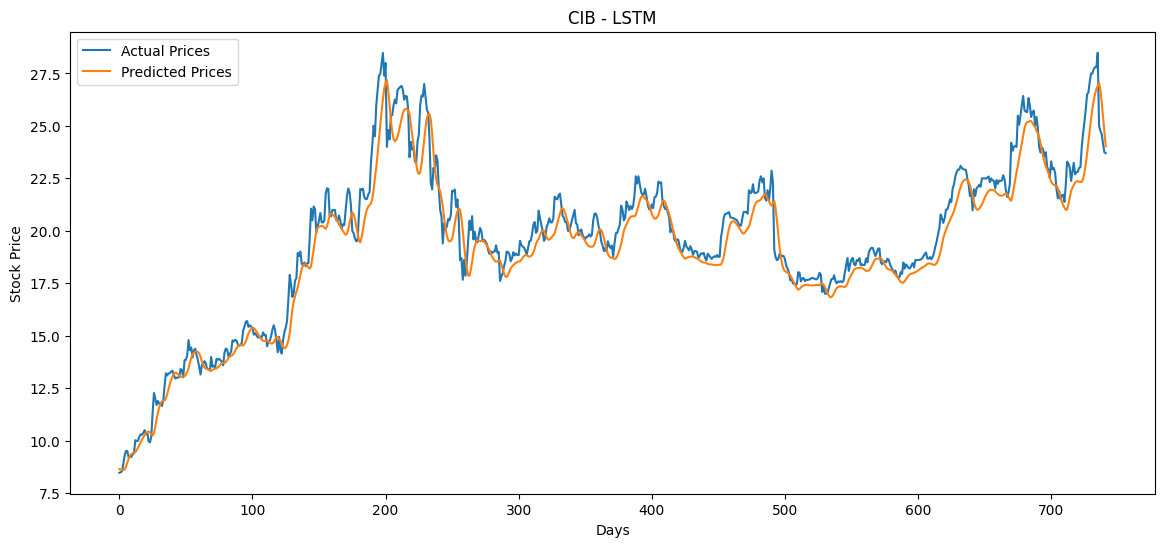


REAL LSTM MODEL FOR: CAE
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - loss: 8.2813e-04 - val_loss: 0.0012
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 1.6541e-04 - val_loss: 0.0020
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - loss: 1.4750e-04 - val_loss: 8.4270e-04
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 1.2058e-04 - val_loss: 0.0021
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 1.2042e-04 - val_loss: 0.0018
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 9.6172e-05 - val_loss: 0.0011
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 9.7590e-05 - val_loss: 0.0016
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - loss: 8.8556e-05 - val_loss: 0.0011
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 9.0862e-05 - val_loss: 0.0020
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 1.0042e-04 - val_loss: 0.0032
Epoch 11/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 8.7176e-05 - val_loss: 0.0014
Epoch 12/20
99/99 ━━━━━━

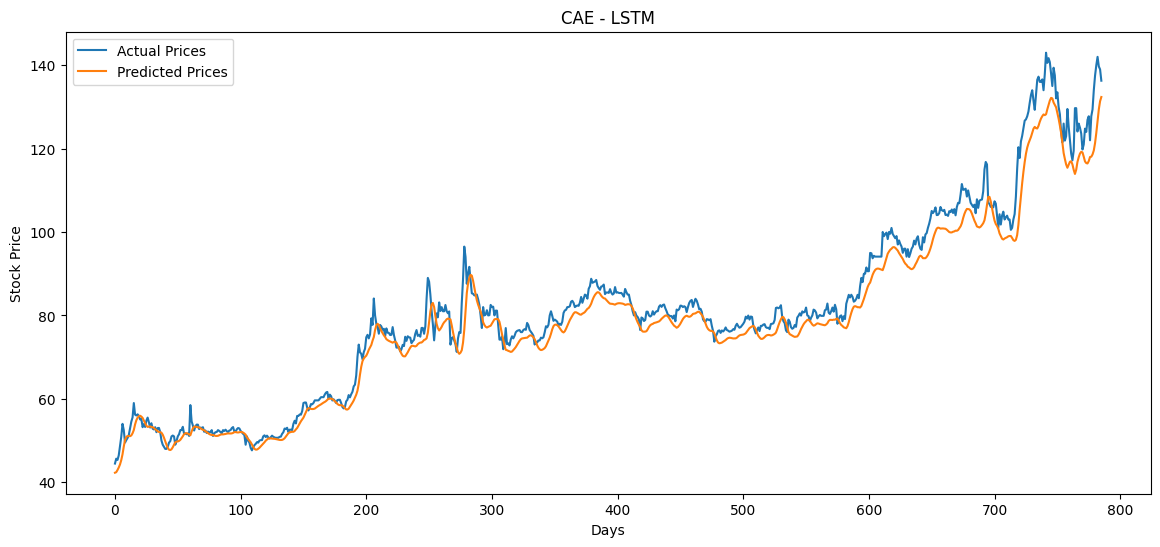


REAL LSTM MODEL FOR: HDB
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - loss: 1.0156e-04 - val_loss: 8.7545e-04
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 1.2188e-05 - val_loss: 5.6114e-04
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 1.0970e-05 - val_loss: 4.6496e-04
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - loss: 9.3981e-06 - val_loss: 7.5059e-04
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 9.0132e-06 - val_loss: 5.7345e-04
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - loss: 9.9941e-06 - val_loss: 3.8972e-04
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 8.7962e-06 - val_loss: 5.7648e-04
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 8.2089e-06 - val_loss: 4.4276e-04
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 9.1288e-06 - val_loss: 3.4258e-04
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - loss: 7.9309e-06 - val_loss: 3.3558e-04
Epoch 11/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 8.1627e-06 - val_

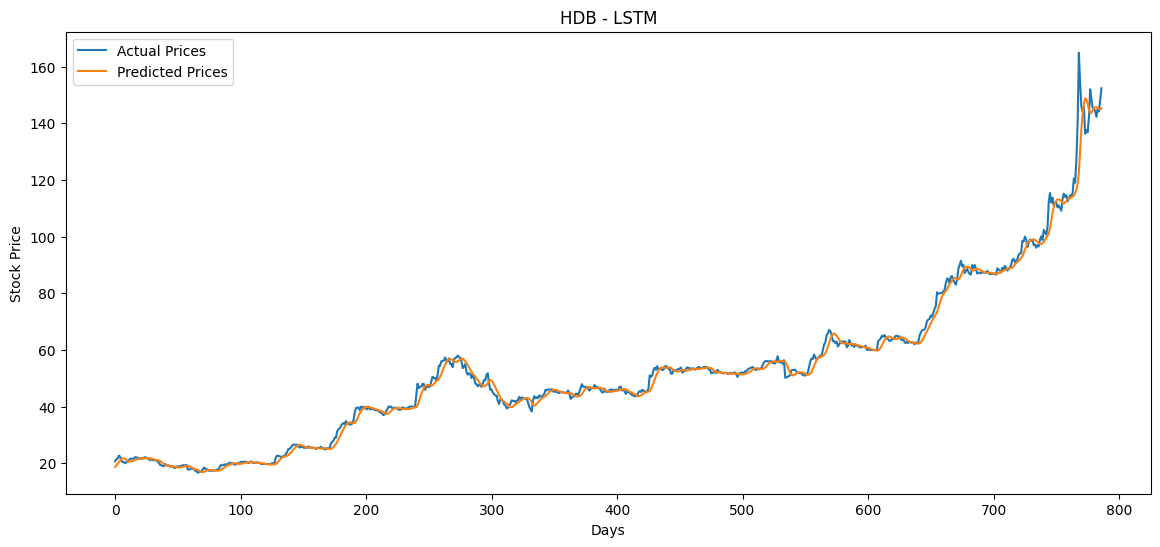

In [ ]:
cib_lstm = run_real_lstm(cib, "CIB")

cae_lstm = run_real_lstm(cae, "CAE")

hdb_lstm = run_real_lstm(hdb, "HDB")

In [ ]:
lstm_results = [
    cib_lstm,
    cae_lstm,
    hdb_lstm
]

lstm_results_df = pd.DataFrame(lstm_results)

print(lstm_results_df)

  Dataset       MAE      RMSE        R2  MAPE (%)  Forecast Accuracy (%)
0     CIB  0.704043  0.961150  0.935169  3.450375              96.549625
1     CAE  3.169485  4.310638  0.961176  3.596697              96.403303
2     HDB  1.381373  2.758926  0.990035  2.569540              97.430460


In [ ]:
def forecast_future_prices(df, dataset_name):

    print("\n" + "=" * 60)
    print(f"FUTURE FORECAST FOR: {dataset_name}")
    print("=" * 60)

    # ---------------------------------------------------
    # SELECT CLOSE PRICES
    # ---------------------------------------------------

    data = df[['Close']]

    # ---------------------------------------------------
    # SCALE DATA
    # ---------------------------------------------------

    scaler = MinMaxScaler(feature_range=(0,1))

    scaled_data = scaler.fit_transform(data)

    # ---------------------------------------------------
    # CREATE SEQUENCES
    # ---------------------------------------------------

    sequence_length = 60

    X = []
    y = []

    for i in range(sequence_length, len(scaled_data)):

        X.append(
            scaled_data[i-sequence_length:i, 0]
        )

        y.append(
            scaled_data[i, 0]
        )

    X = np.array(X)

    y = np.array(y)

    X = np.reshape(
        X,
        (X.shape[0], X.shape[1], 1)
    )

    # ---------------------------------------------------
    # BUILD MODEL
    # ---------------------------------------------------

    model = Sequential()

    model.add(
        LSTM(
            units=64,
            return_sequences=True,
            input_shape=(X.shape[1], 1)
        )
    )

    model.add(Dropout(0.2))

    model.add(
        LSTM(
            units=64,
            return_sequences=False
        )
    )

    model.add(Dropout(0.2))

    model.add(Dense(25))

    model.add(Dense(1))

    # ---------------------------------------------------
    # COMPILE MODEL
    # ---------------------------------------------------

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    # ---------------------------------------------------
    # TRAIN MODEL
    # ---------------------------------------------------

    model.fit(
        X,
        y,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    # ---------------------------------------------------
    # FUTURE FORECASTING
    # ---------------------------------------------------

    future_days = 10

    last_60_days = scaled_data[-60:]

    future_input = last_60_days.reshape(1,60,1)

    future_predictions = []

    for i in range(future_days):

        next_prediction = model.predict(
            future_input,
            verbose=0
        )

        future_predictions.append(
            next_prediction[0,0]
        )

        future_input = np.append(
            future_input[:,1:,:],
            [[[next_prediction[0,0]]]],
            axis=1
        )

    # ---------------------------------------------------
    # INVERSE TRANSFORM
    # ---------------------------------------------------

    future_predictions = scaler.inverse_transform(
        np.array(future_predictions).reshape(-1,1)
    )

    # ---------------------------------------------------
    # PRINT FUTURE PRICES
    # ---------------------------------------------------

    print("\nPREDICTED PRICES FOR NEXT 10 DAYS\n")

    for day, price in enumerate(
        future_predictions,
        start=1
    ):

        print(f"Day {day}: {price[0]:.2f}")

    # ---------------------------------------------------
    # FUTURE PLOT
    # ---------------------------------------------------

    plt.figure(figsize=(10,5))

    plt.plot(
        range(1,11),
        future_predictions,
        marker='o'
    )

    plt.title(
        f'{dataset_name} - Future Forecast'
    )

    plt.xlabel('Future Days')

    plt.ylabel('Predicted Price')

    plt.grid(True)

    plt.show()

    return future_predictions


FUTURE FORECAST FOR: CIB


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



PREDICTED PRICES FOR NEXT 10 DAYS

Day 1: 24.00
Day 2: 23.84
Day 3: 23.79
Day 4: 23.78
Day 5: 23.79
Day 6: 23.81
Day 7: 23.83
Day 8: 23.85
Day 9: 23.86
Day 10: 23.86


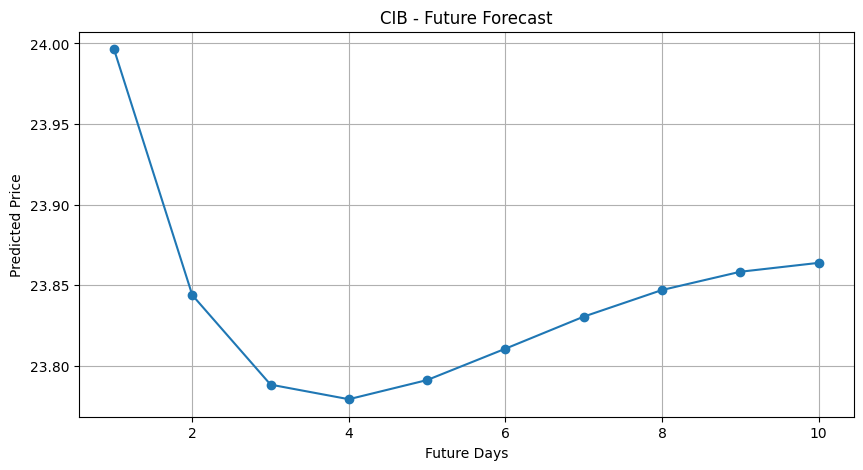


FUTURE FORECAST FOR: CAE


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



PREDICTED PRICES FOR NEXT 10 DAYS

Day 1: 140.03
Day 2: 140.22
Day 3: 140.47
Day 4: 140.75
Day 5: 141.03
Day 6: 141.30
Day 7: 141.58
Day 8: 141.85
Day 9: 142.12
Day 10: 142.39


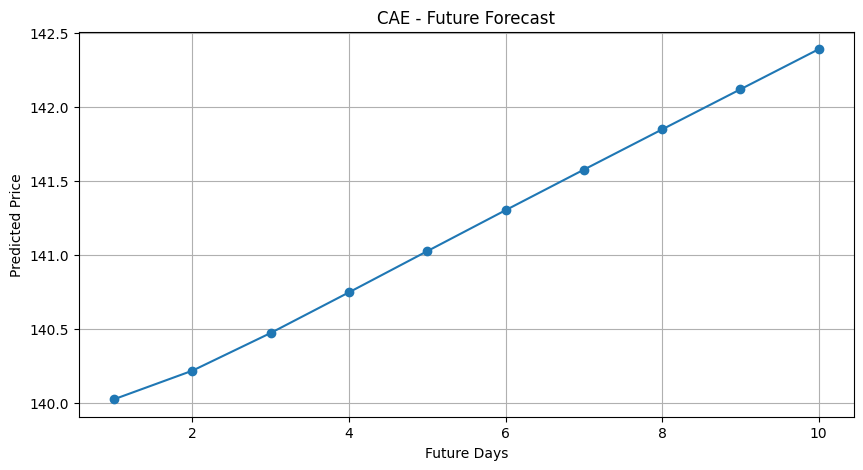


FUTURE FORECAST FOR: HDB


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



PREDICTED PRICES FOR NEXT 10 DAYS

Day 1: 152.34
Day 2: 153.98
Day 3: 155.64
Day 4: 157.29
Day 5: 158.96
Day 6: 160.63
Day 7: 162.32
Day 8: 164.01
Day 9: 165.71
Day 10: 167.42


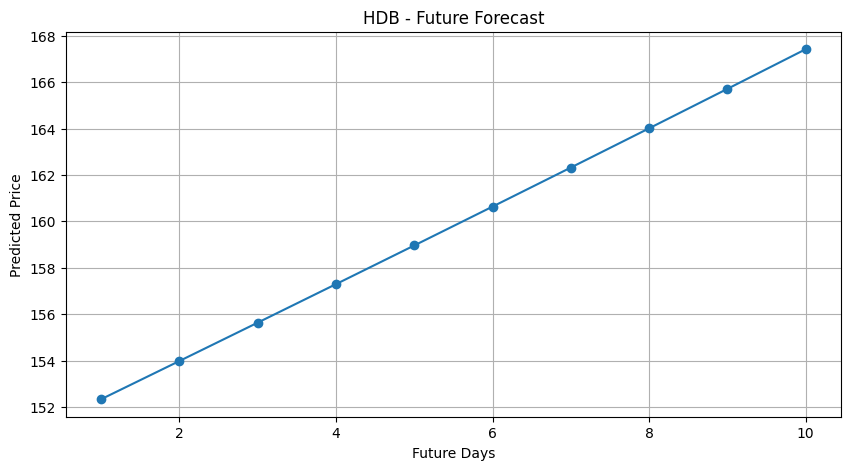

In [ ]:
cib_future = forecast_future_prices(cib, "CIB")

cae_future = forecast_future_prices(cae, "CAE")

hdb_future = forecast_future_prices(hdb, "HDB")

In [ ]:
def investment_advisor(
    dataset_name,
    current_price,
    predicted_price,
    volatility
):

    print("\n" + "=" * 60)
    print(f"SMART INVESTMENT ADVISOR — {dataset_name}")
    print("=" * 60)

    # ---------------------------------------------------
    # EXPECTED RETURN %
    # ---------------------------------------------------

    expected_return = (
        (predicted_price - current_price)
        / current_price
    ) * 100

    # ---------------------------------------------------
    # PRINT DATA
    # ---------------------------------------------------

    print(f"Current Price: {current_price:.2f}")

    print(f"Predicted Price: {predicted_price:.2f}")

    print(f"Expected Return: {expected_return:.2f}%")

    print(f"Volatility: {volatility:.2f}%")

    # ---------------------------------------------------
    # DECISION LOGIC
    # ---------------------------------------------------

    if expected_return > 5 and volatility < 3:

        decision = "BUY"

        reason = (
            "Strong predicted growth with low risk."
        )

    elif expected_return > 1 and volatility < 6:

        decision = "HOLD"

        reason = (
            "Moderate growth potential with acceptable risk."
        )

    else:

        decision = "SELL"

        reason = (
            "Weak future growth or high market risk."
        )

    # ---------------------------------------------------
    # OUTPUT
    # ---------------------------------------------------

    print("\nRECOMMENDATION:", decision)

    print("REASON:", reason)

    # ---------------------------------------------------
    # RETURN RESULTS
    # ---------------------------------------------------

    return {
        "Dataset": dataset_name,
        "Current Price": current_price,
        "Predicted Price": predicted_price,
        "Expected Return (%)": expected_return,
        "Volatility (%)": volatility,
        "Decision": decision,
        "Reason": reason
    }

In [ ]:
# CIB
cib_advice = investment_advisor(
    "CIB",
    cib['Close'].iloc[-1],
    cib_future[-1][0],
    cib_volatility
)

# CAE
cae_advice = investment_advisor(
    "CAE",
    cae['Close'].iloc[-1],
    cae_future[-1][0],
    cae_volatility
)

# HDB
hdb_advice = investment_advisor(
    "HDB",
    hdb['Close'].iloc[-1],
    hdb_future[-1][0],
    hdb_volatility
)


SMART INVESTMENT ADVISOR — CIB
Current Price: 23.70
Predicted Price: 23.86
Expected Return: 0.69%
Volatility: 2.04%

RECOMMENDATION: SELL
REASON: Weak future growth or high market risk.

SMART INVESTMENT ADVISOR — CAE
Current Price: 136.28
Predicted Price: 142.39
Expected Return: 4.48%
Volatility: 1.83%

RECOMMENDATION: HOLD
REASON: Moderate growth potential with acceptable risk.

SMART INVESTMENT ADVISOR — HDB
Current Price: 152.36
Predicted Price: 167.42
Expected Return: 9.88%
Volatility: 2.06%

RECOMMENDATION: BUY
REASON: Strong predicted growth with low risk.


In [ ]:
def calculate_volatility(df):

    # ---------------------------------------------------
    # COPY DATAFRAME
    # ---------------------------------------------------

    df = df.copy()

    # ---------------------------------------------------
    # ENSURE NUMERIC VALUES
    # ---------------------------------------------------

    df['Close'] = pd.to_numeric(
        df['Close'],
        errors='coerce'
    )

    # ---------------------------------------------------
    # REMOVE MISSING VALUES
    # ---------------------------------------------------

    df = df.dropna(subset=['Close'])

    # ---------------------------------------------------
    # REMOVE ZERO OR NEGATIVE PRICES
    # ---------------------------------------------------

    df = df[df['Close'] > 0]

    # ---------------------------------------------------
    # DAILY RETURNS
    # ---------------------------------------------------

    returns = df['Close'].pct_change()

    # ---------------------------------------------------
    # REMOVE INVALID VALUES
    # ---------------------------------------------------

    returns = returns.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    # ---------------------------------------------------
    # VOLATILITY
    # ---------------------------------------------------

    volatility = returns.std() * 100

    # ---------------------------------------------------
    # RETURN RESULT
    # ---------------------------------------------------

    return round(volatility, 2)

In [ ]:
cib_volatility = calculate_volatility(cib)

cae_volatility = calculate_volatility(cae)

hdb_volatility = calculate_volatility(hdb)

print("CIB Volatility:", cib_volatility)

print("CAE Volatility:", cae_volatility)

print("HDB Volatility:", hdb_volatility)

CIB Volatility: 2.04
CAE Volatility: 1.83
HDB Volatility: 2.06


In [ ]:
# ---------------------------------------------------
# CURRENT STOCK PRICE
# ---------------------------------------------------

cib_current_price = cib['Close'].iloc[-1]

# ---------------------------------------------------
# USE LSTM FUTURE PREDICTION
# LAST PREDICTED FUTURE PRICE
# ---------------------------------------------------

cib_predicted_price = cib_future[-1][0]

# ---------------------------------------------------
# RISK / VOLATILITY
# ---------------------------------------------------

cib_volatility = calculate_volatility(cib)

# ---------------------------------------------------
# INVESTMENT ADVISOR
# ---------------------------------------------------

cib_advice = investment_advisor(
    "CIB",
    cib_current_price,
    cib_predicted_price,
    cib_volatility
)


SMART INVESTMENT ADVISOR — CIB
Current Price: 23.70
Predicted Price: 23.86
Expected Return: 0.69%
Volatility: 2.04%

RECOMMENDATION: SELL
REASON: Weak future growth or high market risk.


In [ ]:
# ---------------------------------------------------
# CAE CURRENT STOCK PRICE
# ---------------------------------------------------

cae_current_price = cae['Close'].iloc[-1]

# ---------------------------------------------------
# USE LSTM FUTURE PREDICTION
# LAST PREDICTED FUTURE PRICE
# ---------------------------------------------------

cae_predicted_price = cae_future[-1][0]

# ---------------------------------------------------
# RISK / VOLATILITY
# ---------------------------------------------------

cae_volatility = calculate_volatility(cae)

# ---------------------------------------------------
# INVESTMENT ADVISOR
# ---------------------------------------------------

cae_advice = investment_advisor(
    "CAE",
    cae_current_price,
    cae_predicted_price,
    cae_volatility
)


# ---------------------------------------------------
# HDB CURRENT STOCK PRICE
# ---------------------------------------------------

hdb_current_price = hdb['Close'].iloc[-1]

# ---------------------------------------------------
# USE LSTM FUTURE PREDICTION
# LAST PREDICTED FUTURE PRICE
# ---------------------------------------------------

hdb_predicted_price = hdb_future[-1][0]

# ---------------------------------------------------
# RISK / VOLATILITY
# ---------------------------------------------------

hdb_volatility = calculate_volatility(hdb)

# ---------------------------------------------------
# INVESTMENT ADVISOR
# ---------------------------------------------------

hdb_advice = investment_advisor(
    "HDB",
    hdb_current_price,
    hdb_predicted_price,
    hdb_volatility
)


SMART INVESTMENT ADVISOR — CAE
Current Price: 136.28
Predicted Price: 142.39
Expected Return: 4.48%
Volatility: 1.83%

RECOMMENDATION: HOLD
REASON: Moderate growth potential with acceptable risk.

SMART INVESTMENT ADVISOR — HDB
Current Price: 152.36
Predicted Price: 167.42
Expected Return: 9.88%
Volatility: 2.06%

RECOMMENDATION: BUY
REASON: Strong predicted growth with low risk.


In [ ]:
# ---------------------------------------------------
# COMBINE INVESTMENT ADVISOR RESULTS
# ---------------------------------------------------

advisor_results = pd.DataFrame([

    cib_advice,

    cae_advice,

    hdb_advice

])

# ---------------------------------------------------
# DISPLAY RESULTS
# ---------------------------------------------------

print(advisor_results)

  Dataset  Current Price  Predicted Price  Expected Return (%)  \
0     CIB      23.700000        23.863808             0.691172   
1     CAE     136.279999       142.388336             4.482197   
2     HDB     152.360001       167.415878             9.881778   

   Volatility (%) Decision                                           Reason  
0            2.04     SELL          Weak future growth or high market risk.  
1            1.83     HOLD  Moderate growth potential with acceptable risk.  
2            2.06      BUY           Strong predicted growth with low risk.  


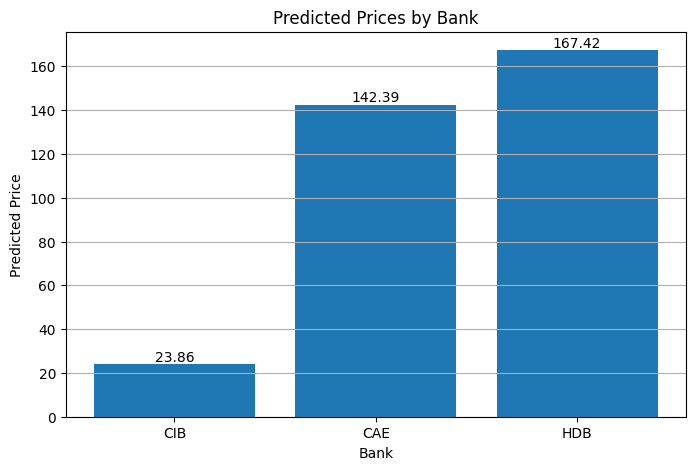

In [ ]:
# ---------------------------------------------------
# PREDICTED PRICES BAR CHART
# ---------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    advisor_results['Dataset'],
    advisor_results['Predicted Price']
)

# ---------------------------------------------------
# TITLES & LABELS
# ---------------------------------------------------

plt.title('Predicted Prices by Bank')

plt.xlabel('Bank')

plt.ylabel('Predicted Price')

# ---------------------------------------------------
# SHOW VALUES ON BARS
# ---------------------------------------------------

for i, value in enumerate(
    advisor_results['Predicted Price']
):

    plt.text(
        i,
        value,
        f'{value:.2f}',
        ha='center',
        va='bottom'
    )

# ---------------------------------------------------
# SHOW GRAPH
# ---------------------------------------------------

plt.grid(axis='y')

plt.show()

In [ ]:
# ---------------------------------------------------
# SAVE ADVISOR RESULTS TO CSV
# ---------------------------------------------------

advisor_results.to_csv(
    "investment_advisor_results.csv",
    index=False
)

# ---------------------------------------------------
# CONFIRMATION MESSAGE
# ---------------------------------------------------

print("Investment advisor results saved successfully.")

Investment advisor results saved successfully.
